## Netflix Case Study



*   How has the number of movies released per year changed over the last 20-30 years?
* Comparison of tv shows vs. movies.
* What is the best time to launch a TV show?
* Analysis of actors/directors of different types of shows/movies.
* Does Netflix has more focus on TV Shows than movies in recent years
* Understanding what content is available in different countries



In [4]:
# Download all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the data




In [5]:
data = pd.read_csv('netflix_titles.csv')
data.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [6]:
# Checking the basic information of dataset

print('The sie of the dataframe is:',data.shape)

The sie of the dataframe is: (8807, 12)


#### The dataframe has 8807 rows and 12 columns

In [7]:
# Checking the datatypes of columns

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Inference:
1.   Overall it has 12 columns, all are object data type except 1 which is release_year
2.   "director, cast, country, date_added" are the columns with major null-values
3. "date_added" is currently in object data type, will convert to datetime
data type





In [8]:
# Converting date_added data type

data['date_added'] = pd.to_datetime(data['date_added' ])

In [9]:
# Checking number of unique values for each column

total_unique = data.nunique()
total_values = data.count()

proportion = round(total_unique/total_values,2)

summary = pd.DataFrame({"Total Values": total_values,"Total Unique Values" :total_unique,
                        "Proportion of unique values": proportion})
summary

,Total Values,Total Unique Values,Proportion of unique values
show_id,8807,8807,1.00
type,8807,2,0.00
title,8807,8807,1.00
director,6173,4528,0.73
cast,7982,7692,0.96
country,7976,748,0.09
date_added,8797,1714,0.19
release_year,8807,74,0.01
rating,8803,17,0.00
duration,8804,220,0.02


### Inferences:

1. show_id and title have highest value and it shows that they uniquely identifies a row
2. "director, cast & country" has large number of unique values but less than total number of rows which means that they are asoociated with multiple titles
3. date_added: There are 1714 unique dates when content was added. This indicates that content was added on multiple dates
4. release_year: 74 unique release years are present, suggesting that the dataset covers content released over a significant period (around 74 years)
5. listed_in: With 514 unique values, this column representing genres or categories is quite diverse.

## Pre-processing of data

In [10]:
# Date columns has null values, since its only 10 rows hence dropping it

data.dropna(subset = ['date_added'],inplace = True)

data.shape

(8797, 12)

In [11]:
# Exploding the cast column

data['cast_mod'] = data['cast'].str.split(',')
data = data.explode('cast_mod')

In [12]:
# Address the missing values in the 'director', 'cast', 'country', and 'rating' columns.

data['director'].fillna('Unknown', inplace=True)
data['cast_mod'].fillna('Unknown', inplace=True)
data['country'].fillna('Unknown', inplace=True)
data['rating'].fillna('Unknown', inplace=True)

/tmp/ipython-input-3733216221.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['director'].fillna('Unknown', inplace=True)
/tmp/ipython-input-3733216221.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64882 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       64882 non-null  object        
 1   type          64882 non-null  object        
 2   title         64882 non-null  object        
 3   director      64882 non-null  object        
 4   cast          64057 non-null  object        
 5   country       64882 non-null  object        
 6   date_added    64882 non-null  datetime64[ns]
 7   release_year  64882 non-null  int64         
 8   rating        64882 non-null  object        
 9   duration      64879 non-null  object        
 10  listed_in     64882 non-null  object        
 11  description   64882 non-null  object        
 12  cast_mod      64882 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(11)
memory usage: 6.9+ MB


In [14]:
# Statistical summarization

data.describe()

,date_added,release_year
count,64882,64882.000000
mean,2019-07-02 21:39:43.983231232,2013.640732
min,2008-01-01 00:00:00,1925.000000
25%,2018-07-13 00:00:00,2012.000000
50%,2019-10-01 00:00:00,2017.000000
75%,2020-09-30 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.927442


#### Inferences

1. The date added range is from 2008 to 2021, which is covering span of 13 years.
2. Netflix has added content that was originally released as far back as 1925, but they only started adding content to their platform (based on this dataset) in 2008. This difference highlights that Netflix acquires and adds content that was produced over a long period before it became available on their platform.

In [15]:
data.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,cast_mod
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Unknown
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Ama Qamata


In [16]:
# Top 10 countries wherer movies and TV shows both were released
top_10_countries = data[data['country'] != 'Unknown']['country'].value_counts().head(10)
top_10_countries

,count
country,
United States,19893
India,7246
Japan,2733
United Kingdom,2117
South Korea,1478
Canada,1278
Spain,1239
Mexico,933
Turkey,923


In [17]:
# However it can be seen that some of the movies / TV Shows were launched in multiple countries
# and entires for which is mentioned in the same columnn, hence need to explode country columns also

data['country_mod'] = data['country'].str.split(',')
data = data.explode('country_mod')
data['country_mod'] = data['country_mod'].str.strip()

# Rereun the code to find out top 10 countries

top_10_countries = data[data['country_mod'] != 'Unknown']['country_mod'].value_counts().head(10)
top_10_countries

,count
country_mod,
United States,27434
India,7789
United Kingdom,5420
Canada,3550
Japan,3444
France,3134
Spain,1926
South Korea,1795
Germany,1779


In [18]:
# We want to do analysis on top 10 countries only, but to ensure that this covers major portion of the data,
# lets check what is the coverage of the row items by these countries, excluding the null values as without country
# information, the findings would be more generic


top_10_countries_perc_coverage = top_10_countries.sum()/data.shape[0]
round(top_10_countries_perc_coverage,2)*100


np.float64(71.0)

In [19]:
# This is covering 68% of the data, since we want to keep a threshold of 80%,
# lets increase the top countries to 15 or 20 and check its coverage proportion

top_15_countries = data[data['country_mod'] != 'Unknown']['country_mod'].value_counts().head(15)
top_15_countries_perc_coverage = top_15_countries.sum()/data.shape[0]


top_20_countries = data[data['country_mod'] != 'Unknown']['country_mod'].value_counts().head(20)
top_20_countries_perc_coverage = top_20_countries.sum()/data.shape[0]

print("Coverage by top 15 countries is:",round(top_15_countries_perc_coverage,2)*100)
print("Coverage by top 20 countries is:",round(top_20_countries_perc_coverage,2)*100)



Coverage by top 15 countries is: 77.0
Coverage by top 20 countries is: 82.0


In [20]:
# Since it satisfies the threshold, hence focusing the analysis on top 20 countries

## Exploratory Data Analysis on top 20 countries

In [21]:
ref_data = data[data['country'].isin(top_20_countries.index)]
ref_data.shape

(43905, 14)

In [22]:
ref_data.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,cast_mod,country_mod
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Unknown,United States
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Mayur More,India


In [23]:
# Amongst the dataset, lets try to understand which is more popular move or TV/Show

ref_data['type'].value_counts(normalize = True)

,proportion
type,
Movie,0.703041
TV Show,0.296959


## Movie Dataset analysis for top 20 countries

In [24]:
# It shows that movie are more popular than TV shows

# Lets explore movie and try to understand the following questions:

# 1. how the number of movies released per year has changed over time within the top 20 countries?
# 2. What are the typical movie lengths in these countries? Are there variations by country?
# 3. What are the most common movie ratings in these countries? Are there differences in rating popularity by country?
# 4. Which movie genres are most frequently listed in these countries? Are there country-specific genre preferences?
# 5. Who are the most prolific directors in movies from these countries?

In [46]:
ref_data_movies = ref_data[ref_data['type']=='Movie']
ref_data_movies.head (2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,cast_mod,country_mod
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Unknown,United States
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,Melissa McCarthy,United States


In [26]:
# To the above analysis, lets add some more columns

ref_data_movies['year'] = ref_data_movies['date_added'].dt.year
ref_data_movies['month'] = ref_data_movies['date_added'].dt.month
ref_data_movies['day'] = ref_data_movies['date_added'].dt.day

/tmp/ipython-input-2942239788.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ref_data_movies['year'] = ref_data_movies['date_added'].dt.year
/tmp/ipython-input-2942239788.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ref_data_movies['month'] = ref_data_movies['date_added'].dt.month
/tmp/ipython-input-2942239788.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [27]:
# Also lets split the listed_in or genre category also;

ref_data_movies['genre'] = ref_data_movies['listed_in'].str.split(',')
ref_data_movies = ref_data_movies.explode('genre')

/tmp/ipython-input-1957520060.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ref_data_movies['genre'] = ref_data_movies['listed_in'].str.split(',')


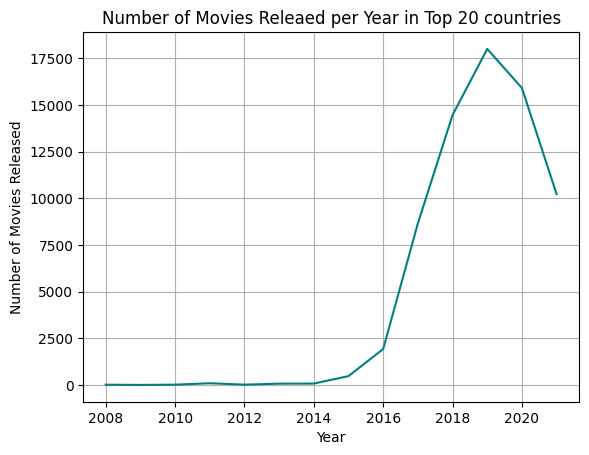

In [28]:
# Lets start addressing the question

# 1. how the number of movies released per year has changed over time within the top 20 countries?

movies_per_year = ref_data_movies['year'].value_counts().sort_index()

plt.plot(movies_per_year.index,movies_per_year.values,color = 'teal')
plt.xlabel('Year')
plt.ylabel('Number of Movies Released')
plt.title('Number of Movies Releaed per Year in Top 20 countries')
plt.grid()
plt.show()

### Inference:

1. The graph clearly shows that from 2008 to 2016, the trend was flat which means # of movies released remains same year after year
2. However from 2017 it started increasing and 2019 was the year where maximum movies were released, one of the major reasons could be the pandemic which forced people to be at home and thus demand of digital movies increased

In [31]:
# 2. What are the typical movie lengths in these countries? Are there variations by country?

# To answer this we need to convert duration which is an object column to int type

# Remove ' min' from the duration string
ref_data_movies['duration'] = ref_data_movies['duration'].str.replace(' min','')

# to check any Null values
# ref_data_movies['duration'].isnull().sum() #----- #3

# Since there are only 3 rows with blank duration, we can drop it

ref_data_movies = ref_data_movies.dropna(subset = ['duration'])

# Convert the duration column to integer type
ref_data_movies['duration'] = ref_data_movies['duration'].astype(int)

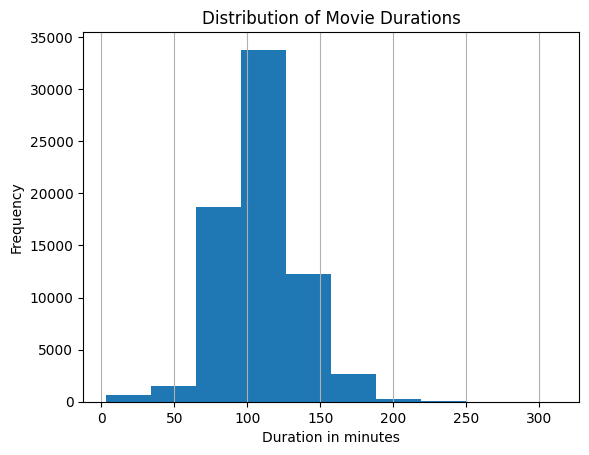

In [32]:
plt.hist(ref_data_movies['duration'])
plt.xlabel('Duration in minutes')
plt.ylabel('Frequency')
plt.grid(axis = 'x')
plt.title('Distribution of Movie Durations')
plt.show()

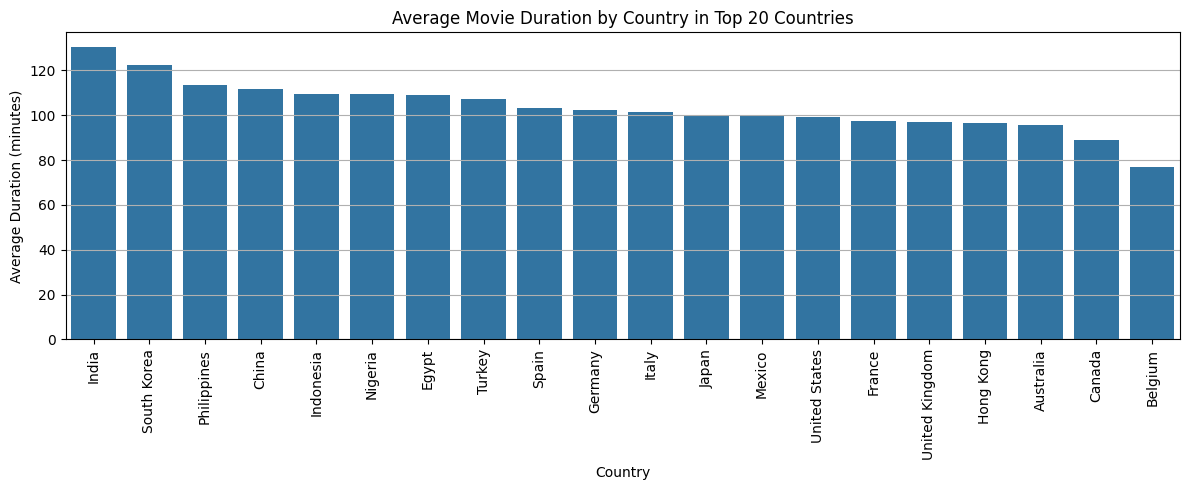

In [33]:
# Calculate the average movie duration for each country

average_duration_by_country = ref_data_movies.groupby('country_mod')['duration'].mean().sort_values(ascending=False)

plt.figure(figsize = (12,5))
sns.barplot(x = average_duration_by_country.index, y = average_duration_by_country.values)
plt.xlabel('Country')
plt.ylabel('Average Duration (minutes)')
plt.title('Average Movie Duration by Country in Top 20 Countries')
plt.grid(axis = 'y')
plt.xticks(rotation=90)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

### Inference

1. On an average the duration of the movies is 100-110 mins
2. Average duration is fairly consistent across many of the top 20 countries, with most falling within a certain range (e.g., 90-110 minutes), but note the countries that are outliers (like India with a significantly higher average)

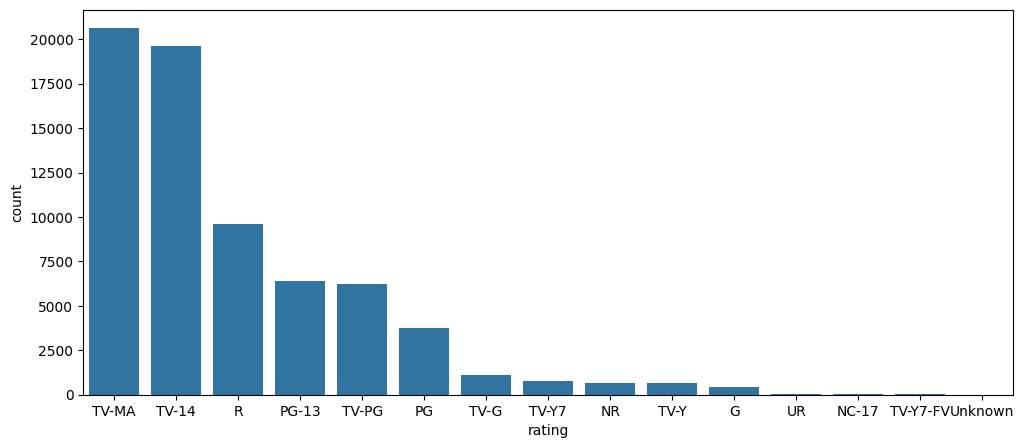

In [34]:
# 3. What are the most common movie ratings in these countries? Are there differences in rating popularity by country?


plt.figure(figsize = (12,5))
sns.countplot(x = ref_data_movies['rating'],order = ref_data_movies['rating'].value_counts().index)
plt.show()


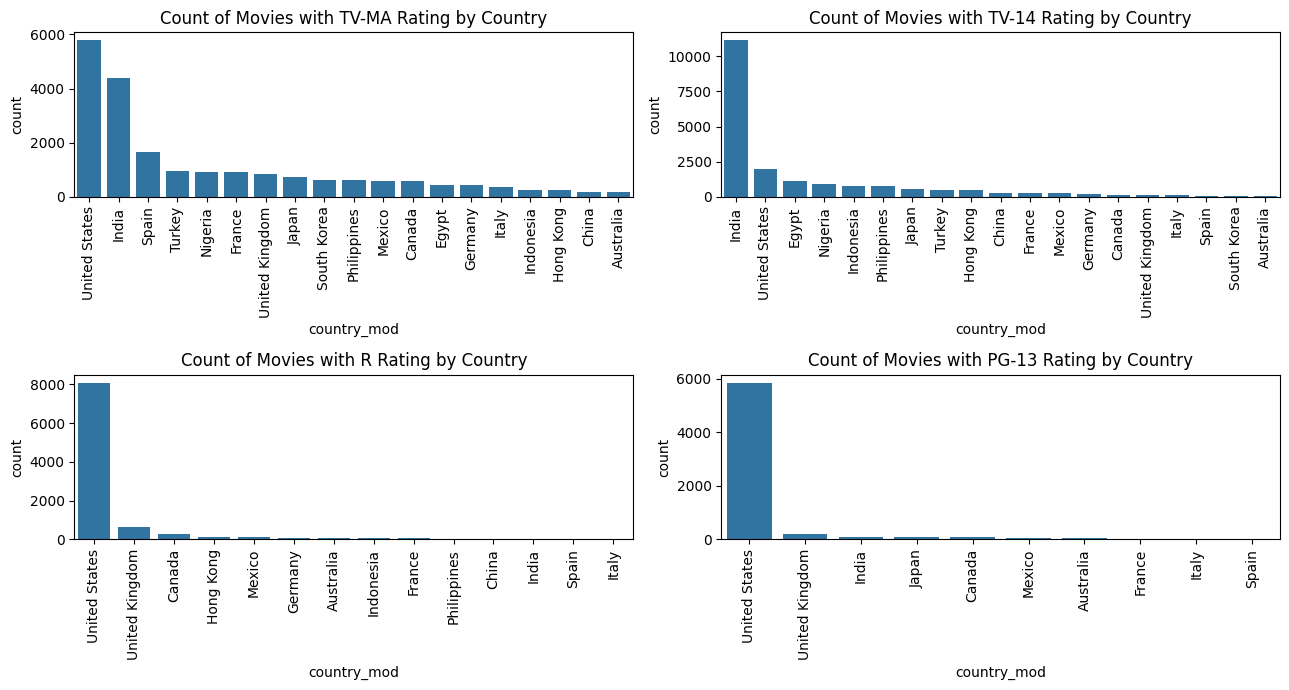

In [35]:
plt.figure(figsize = (13,7))

plt.subplot(2,2,1)
a = ref_data_movies[ref_data_movies['rating'] == 'TV-MA']
sns.countplot(data = a, x = 'country_mod',order = a['country_mod'].value_counts().index)
plt.xticks(rotation = 90)
plt.title('Count of Movies with TV-MA Rating by Country')


plt.subplot(2,2,2)
b = ref_data_movies[ref_data_movies['rating'] == 'TV-14']
sns.countplot(data = b, x = 'country_mod',order = b['country_mod'].value_counts().index)
plt.xticks(rotation = 90)
plt.title('Count of Movies with TV-14 Rating by Country')


plt.subplot(2,2,3)
c = ref_data_movies[ref_data_movies['rating'] == 'R']
sns.countplot(data = c, x = 'country_mod',order = c['country_mod'].value_counts().index)
plt.xticks(rotation = 90)
plt.title('Count of Movies with R Rating by Country')


plt.subplot(2,2,4)
d = ref_data_movies[ref_data_movies['rating'] == 'PG-13']
sns.countplot(data = d, x = 'country_mod',order = d['country_mod'].value_counts().index)
plt.xticks(rotation = 90)
plt.title('Count of Movies with PG-13 Rating by Country')

plt.tight_layout()
plt.show()

### Inference:

1. TV-MA, TV-14, R & PG-13 are common movie ratings in top 20 countries
2. When examining the country-wise trends for the top ratings, the United States has the highest number of movies with R, PG-13, and TV-MA ratings among the top 20 countries. In contrast, India has the highest number of movies with a TV-14 rating among these countries.United States appears to dominate in terms of the sheer volume of movies across several of the top rating categories.

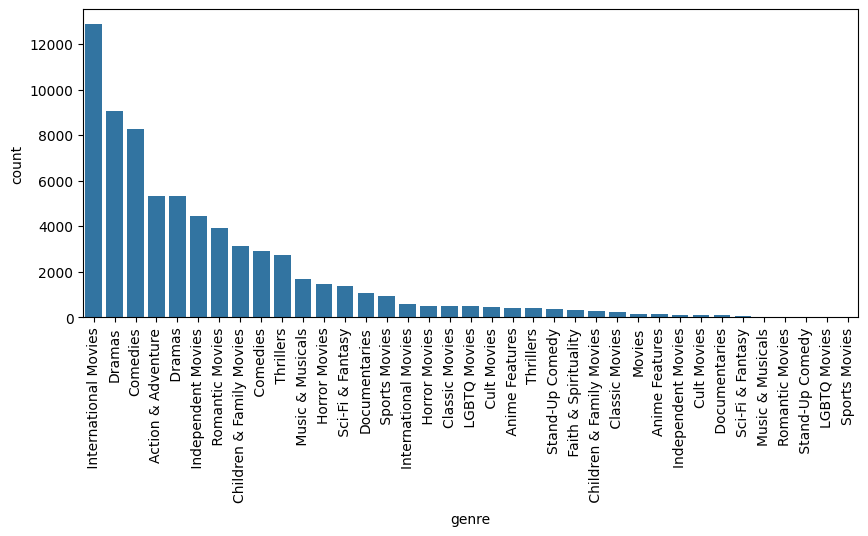

In [36]:
# 4. Which movie genres are most frequently listed in these countries? Are there country-specific genre preferences?

plt.figure(figsize = (10,4))
sns.countplot(data = ref_data_movies, x = 'genre',order = ref_data_movies['genre'].value_counts().index)
plt.xticks(rotation = 90)
plt.show()

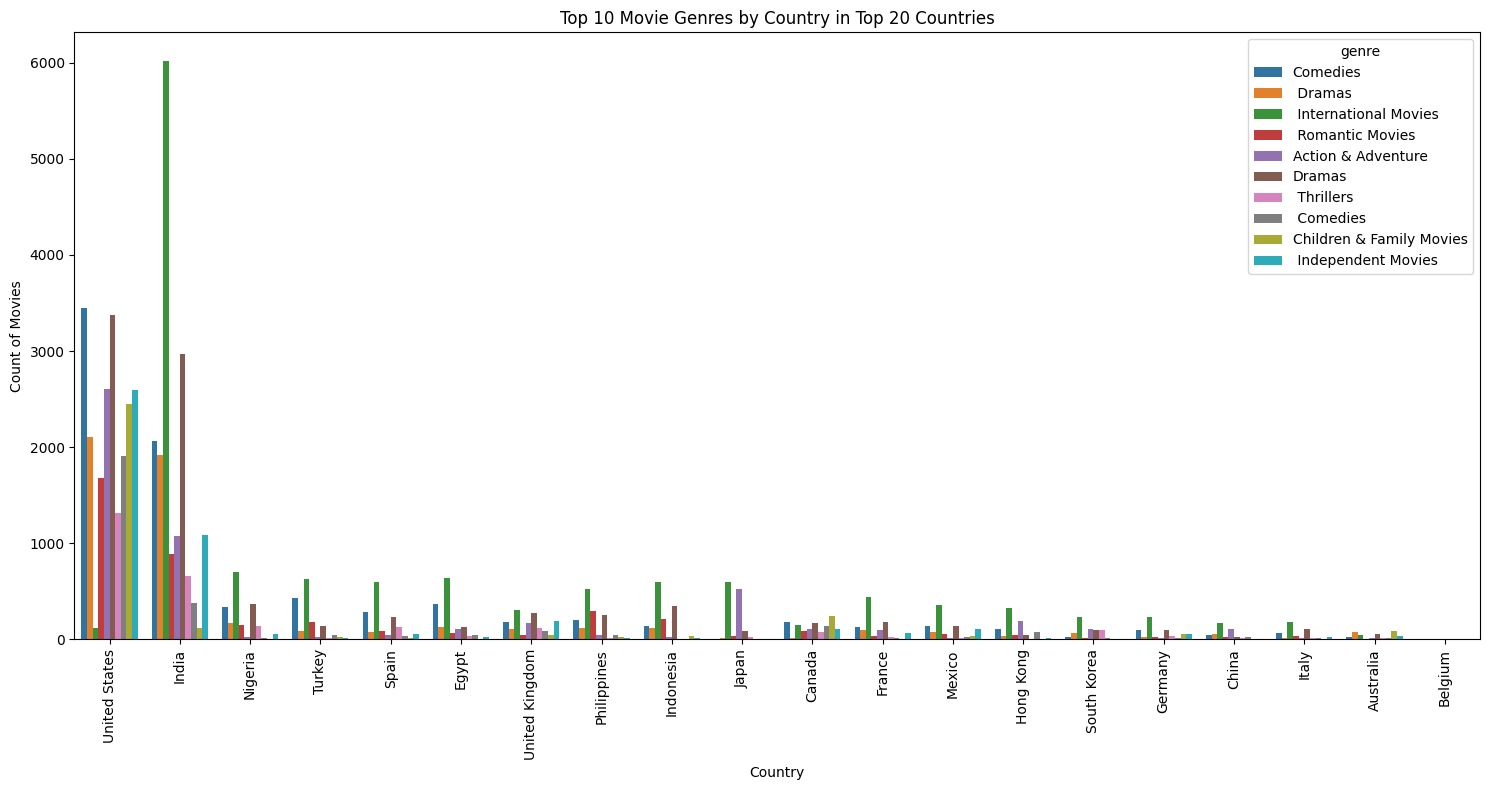

In [37]:
# Identify the top movie genres
top_genres = ref_data_movies['genre'].value_counts().head(10).index.tolist()

# Filter the data to include only the top genres and top 20 countries
filtered_genre_data = ref_data_movies[ref_data_movies['genre'].isin(top_genres)]

# Create a grouped bar chart
plt.figure(figsize=(15, 8))
sns.countplot(data=filtered_genre_data,
              x='country_mod',
              hue='genre',
              order=filtered_genre_data['country_mod'].value_counts().index,
              palette='tab10')
plt.xlabel('Country')
plt.ylabel('Count of Movies')
plt.title('Top 10 Movie Genres by Country in Top 20 Countries')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Inferences:

1. "International Movies," "Dramas," and "Comedies" are the most frequently listed genres overall in the top 20 countries. This suggests a high volume of content in these broad categories.
2. United States has significant counts across almost all of the top 10 genres. This indicates a diverse movie landscape in the US, with high volumes of content in various popular categories like Comedies, Dramas, International Movies, Action & Adventure, and Independent Movies.
3. India has a high count in "International Movies" and "Dramas," aligning with its large film industry. Japan shows a significant presence in "Anime Features" (though not in the top 10 plotted, it's a known strength) and potentially other genres reflected in the "International Movies" category. The UK also has a strong presence across several genres.

In [41]:
# 5. Who are the most prolific directors in movies from these countries?

ref_data_movies['director_mod'] = ref_data_movies['director'].str.split(',')
ref_data_movies = ref_data_movies.explode('director_mod')

ref_data_movies.groupby('country_mod')['director_mod'].value_counts().groupby(level=0).head(1).sort_values(ascending = False)

,,count
country_mod,director_mod,
United States,Peter Farrelly,67584
India,Abhinav Shiv Tiwari,31944
Canada,John Paul Tremblay,1780
Hong Kong,Chow Kwun-wai,1125
Japan,Makoto Hanafusa,1053
Indonesia,Fajar Bustomi,606
Turkey,Yılmaz Erdoğan,437
Egypt,Hazem Fouda,368
Philippines,Cathy Garcia-Molina,356


## Summary

Overall Findings (Top 20 Countries):

1. Content Growth: The number of movies released per year in these countries showed a significant increase starting around 2017, peaking in 2019, and then slightly declining in 2020 and 2021. This suggests a period of rapid growth in movie production and/or acquisition by Netflix in recent years, potentially influenced by factors like the pandemic.
2. Movie Duration: The typical movie duration falls within the 100-110 minute range. While there's some variation, this seems to be a common length for movies in these markets.
3. Popular Ratings: TV-MA, TV-14, R, and PG-13 are the most common movie ratings. This indicates a prevalence of content aimed at mature audiences and teenagers, as well as some content with parental guidance advisories.
4. Dominant Genres: "International Movies," "Dramas," and "Comedies" are the most frequently listed genres. This suggests a high volume of content across these broad categories.

Country-Specific Findings (Top 20 Countries):

1. United States: Appears to be a major hub for movie content, with high counts across most of the top ratings (especially R, PG-13, and TV-MA) and a diverse representation across the top genres. This indicates a large and varied movie market.
2. India: Stands out with the highest average movie duration among the top 20 countries, suggesting a preference for longer films. India also has a strong presence in TV-14 rated movies and is a significant contributor to "International Movies" and "Dramas."
3. United Kingdom: Consistently ranks high across the top ratings and has a strong presence in various genres, indicating a robust and diverse movie market similar to the US, though with lower overall volume.
4. Japan & South Korea: Show notable strengths in specific rating categories (TV-MA and TV-14) and contribute significantly to "International Movies," reflecting the popularity of content from these regions (like anime and K-dramas).
5. Variations in Rating and Genre Preferences: While there are some overarching trends, the analysis of ratings and genres by country revealed variations. For example, some European countries show stronger preferences for certain ratings (like R or TV-MA) over others, and the mix of top genres can differ. This highlights the importance of localized content strategies.

## TV Shows Analysis of top 20 countries

In [45]:
ref_data_tv_shows = ref_data[ref_data['type']=='TV Show']
ref_data_tv_shows.head (2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,cast_mod,country_mod
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Mayur More,India
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Jitendra Kumar,India


In [48]:
# Create a clear copy of the TV shows data to avoid SettingWithCopyWarning
ref_data_tv_shows = ref_data[ref_data['type']=='TV Show'].copy()

# Add year, month, and day columns
ref_data_tv_shows['year'] = ref_data_tv_shows['date_added'].dt.year
ref_data_tv_shows['month'] = ref_data_tv_shows['date_added'].dt.month
ref_data_tv_shows['day'] = ref_data_tv_shows['date_added'].dt.day

# Split and explode the listed_in column to get individual genres
ref_data_tv_shows['genre'] = ref_data_tv_shows['listed_in'].str.split(',')
ref_data_tv_shows = ref_data_tv_shows.explode('genre')
ref_data_tv_shows['genre'] = ref_data_tv_shows['genre'].str.strip() # Remove leading/trailing whitespace from genres

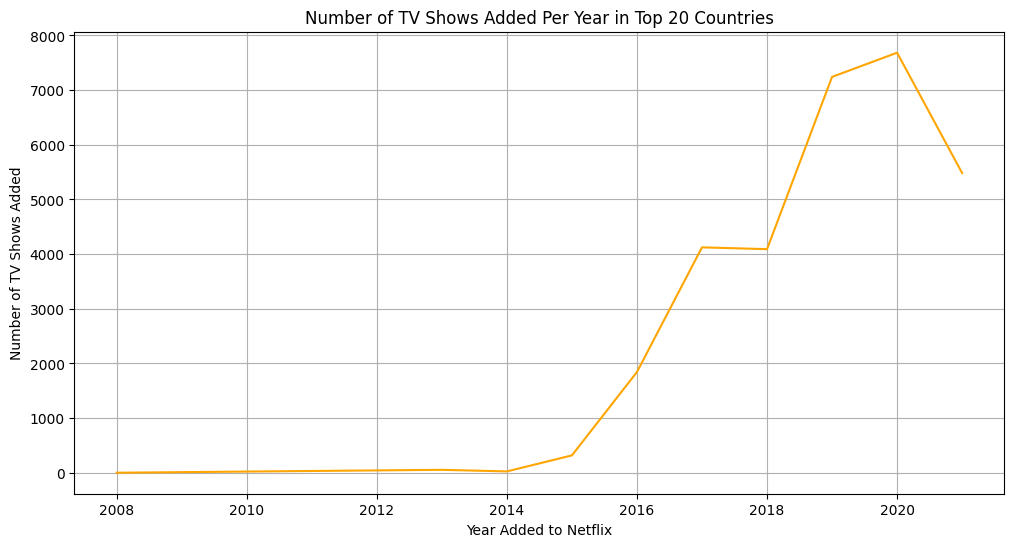

In [49]:
# Calculate the number of TV shows added per year
tv_shows_per_year = ref_data_tv_shows['year'].value_counts().sort_index()

# Plot the number of TV shows added per year
plt.figure(figsize=(12, 6))
plt.plot(tv_shows_per_year.index, tv_shows_per_year.values, color='orange') # Using a different color for distinction
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of TV Shows Added')
plt.title('Number of TV Shows Added Per Year in Top 20 Countries')
plt.grid(True)
plt.show()

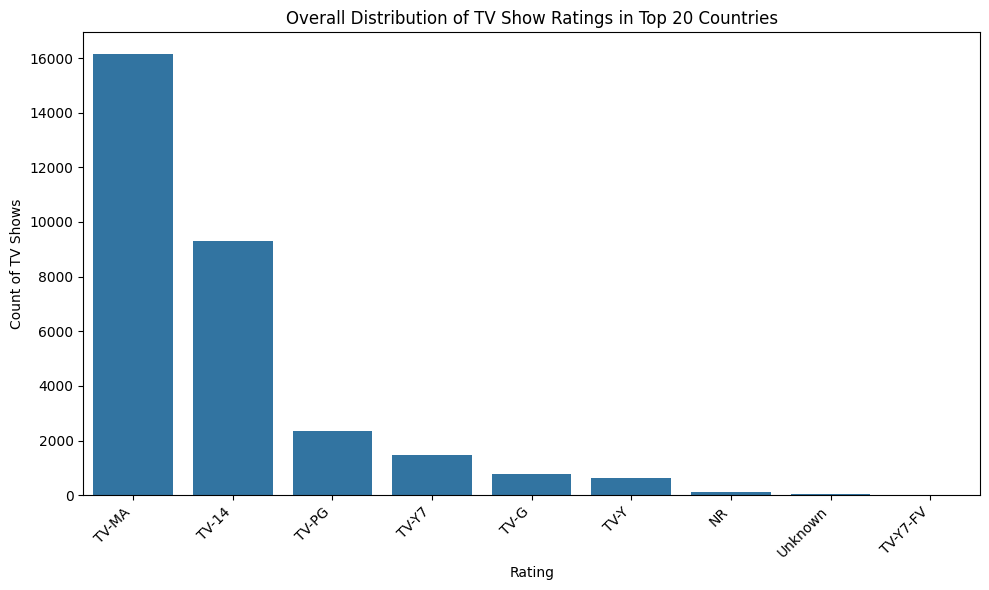

In [58]:
# Calculate the count of each TV show rating
tv_show_ratings_count = ref_data_tv_shows['rating'].value_counts()

# Visualize the overall distribution of TV show ratings
plt.figure(figsize=(10, 6))
sns.countplot(data=ref_data_tv_shows, x='rating', order=tv_show_ratings_count.index)
plt.xlabel('Rating')
plt.ylabel('Count of TV Shows')
plt.title('Overall Distribution of TV Show Ratings in Top 20 Countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

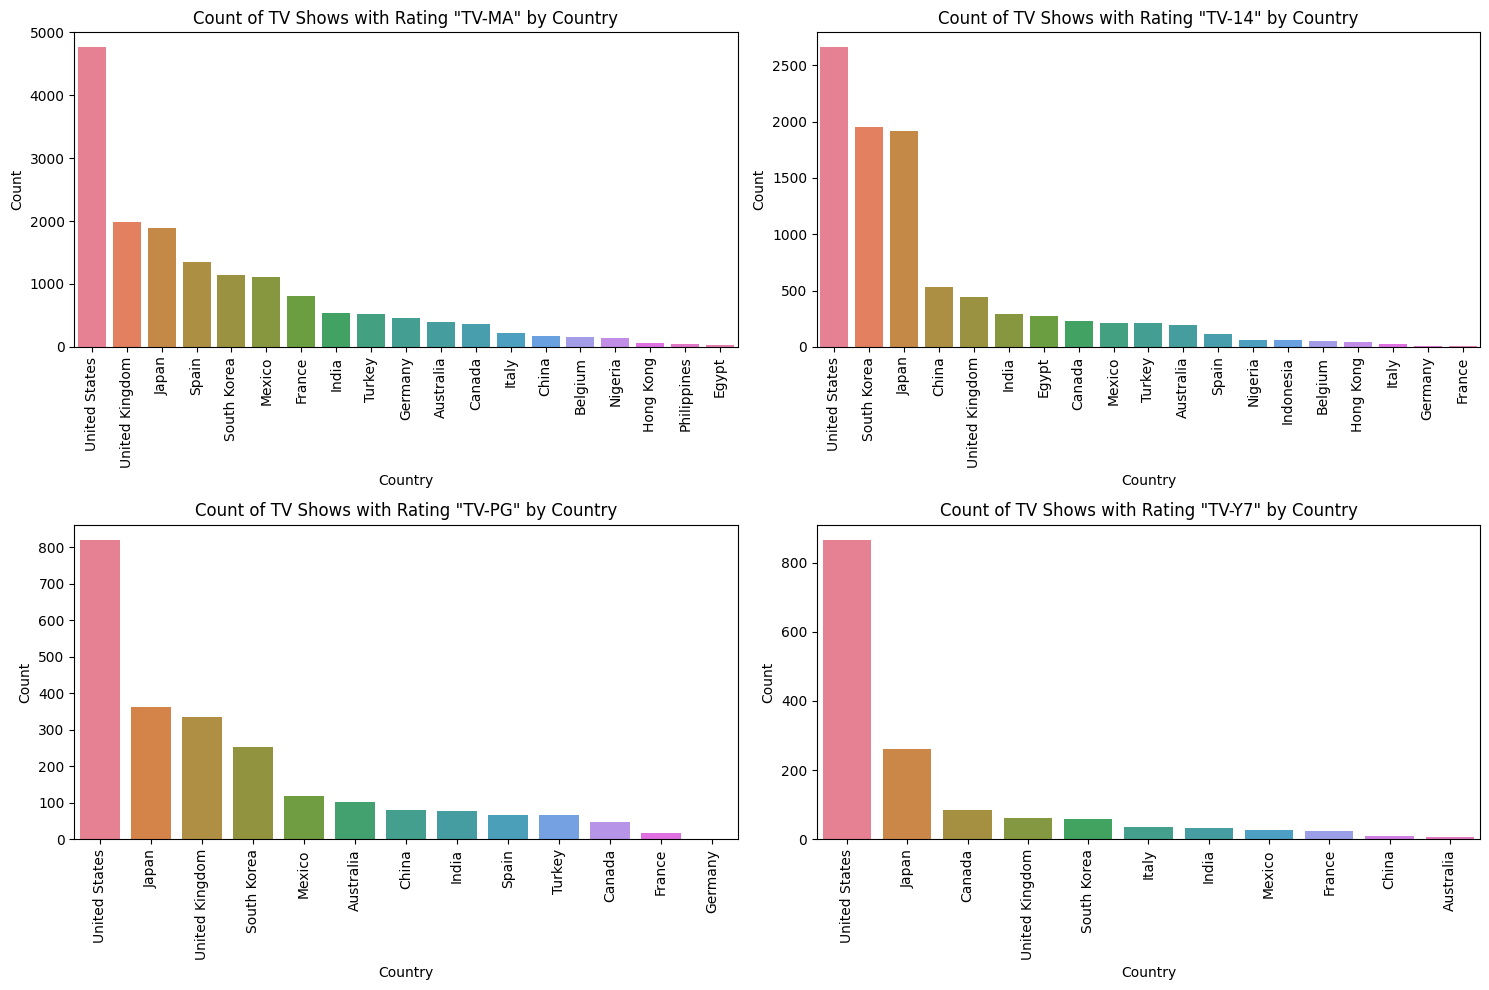

In [60]:
top_4_tv_ratings = ref_data_tv_shows['rating'].value_counts().head(4).index.tolist()

plt.figure(figsize=(15, 10)) # Create a figure to hold the subplots

# Subplot 1: Top 1st Rating
plt.subplot(2, 2, 1)
rating = top_4_tv_ratings[0]
rating_data = ref_data_tv_shows[ref_data_tv_shows['rating'] == rating]
count_by_country = rating_data['country_mod'].value_counts()
sns.barplot(x=count_by_country.index, y=count_by_country.values, hue=count_by_country.index, legend=False)
plt.title(f'Count of TV Shows with Rating "{rating}" by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)

# Subplot 2: Top 2nd Rating
plt.subplot(2, 2, 2)
rating = top_4_tv_ratings[1]
rating_data = ref_data_tv_shows[ref_data_tv_shows['rating'] == rating]
count_by_country = rating_data['country_mod'].value_counts()
sns.barplot(x=count_by_country.index, y=count_by_country.values, hue=count_by_country.index, legend=False)
plt.title(f'Count of TV Shows with Rating "{rating}" by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)

# Subplot 3: Top 3rd Rating
plt.subplot(2, 2, 3)
rating = top_4_tv_ratings[2]
rating_data = ref_data_tv_shows[ref_data_tv_shows['rating'] == rating]
count_by_country = rating_data['country_mod'].value_counts()
sns.barplot(x=count_by_country.index, y=count_by_country.values, hue=count_by_country.index, legend=False)
plt.title(f'Count of TV Shows with Rating "{rating}" by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)

# Subplot 4: Top 4th Rating
plt.subplot(2, 2, 4)
rating = top_4_tv_ratings[3]
rating_data = ref_data_tv_shows[ref_data_tv_shows['rating'] == rating]
count_by_country = rating_data['country_mod'].value_counts()
sns.barplot(x=count_by_country.index, y=count_by_country.values, hue=count_by_country.index,legend=False)
plt.title(f'Count of TV Shows with Rating "{rating}" by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)


plt.tight_layout()
plt.show()

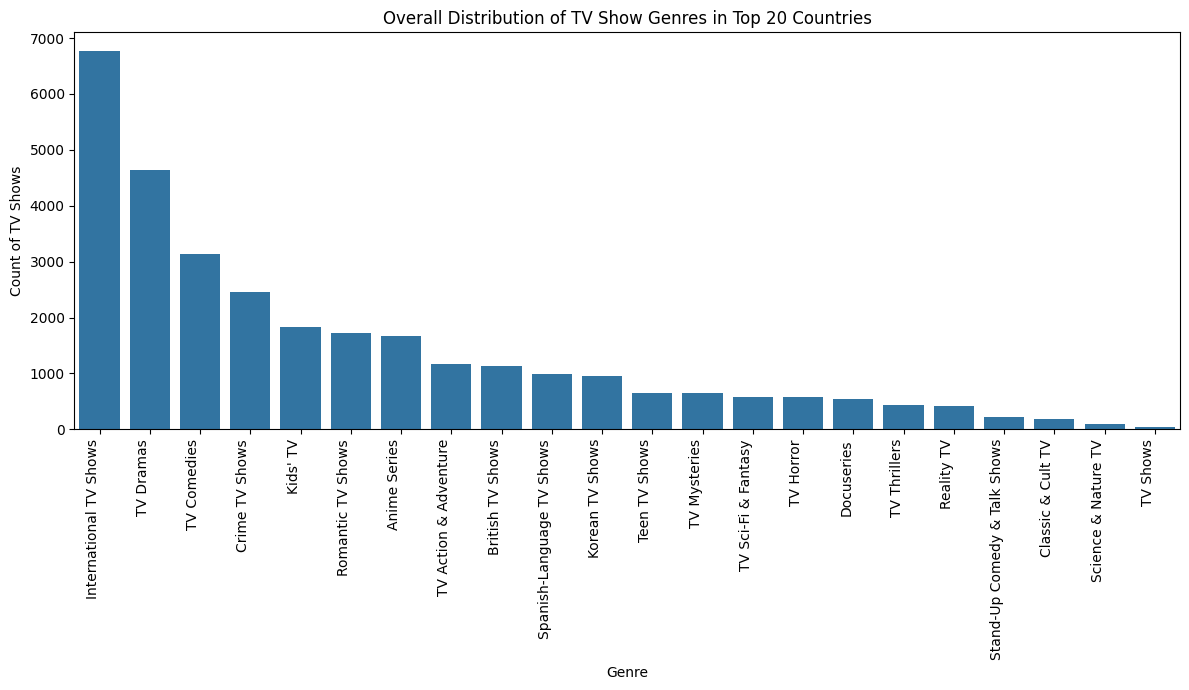

In [63]:
# Calculate the count of each TV show genre
tv_show_genres_count = ref_data_tv_shows['genre'].value_counts()

# Visualize the overall distribution of TV show genres
plt.figure(figsize=(12, 7))
sns.countplot(data=ref_data_tv_shows, x='genre', order=tv_show_genres_count.index, legend=False)
plt.xlabel('Genre')
plt.ylabel('Count of TV Shows')
plt.title('Overall Distribution of TV Show Genres in Top 20 Countries')
plt.xticks(rotation=90, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

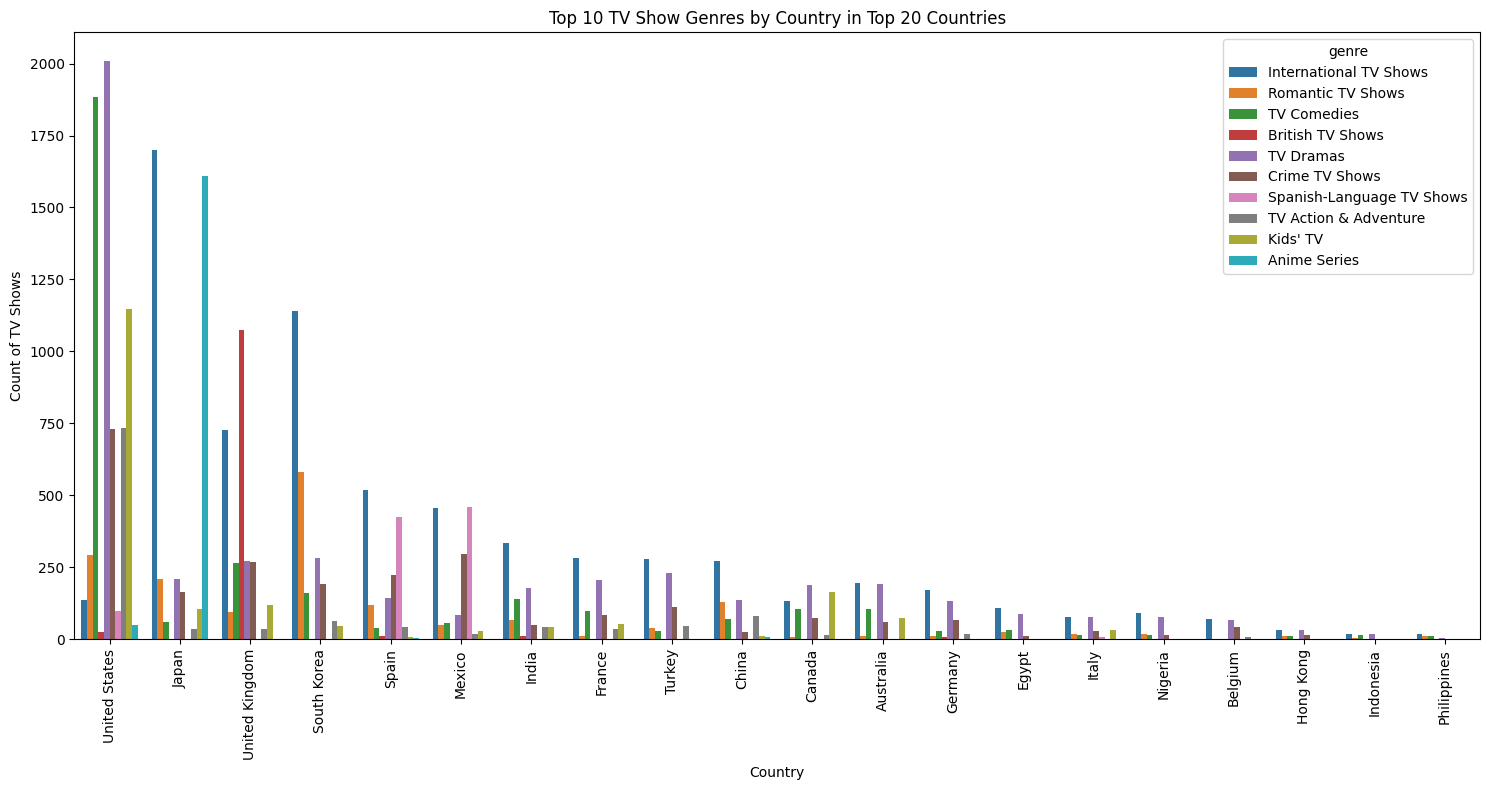

In [56]:
# Identify the top TV show genres
top_tv_genres = ref_data_tv_shows['genre'].value_counts().head(10).index.tolist()

# Filter the data to include only the top TV genres and top 20 countries
filtered_tv_genre_data = ref_data_tv_shows[ref_data_tv_shows['genre'].isin(top_tv_genres)]

# Create a grouped bar chart
plt.figure(figsize=(15, 8))
sns.countplot(data=filtered_tv_genre_data,
              x='country_mod',
              hue='genre',
              order=filtered_tv_genre_data['country_mod'].value_counts().index,
              palette='tab10') # Using a different color palette for variety
plt.xlabel('Country')
plt.ylabel('Count of TV Shows')
plt.title('Top 10 TV Show Genres by Country in Top 20 Countries')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Summary of TV Show Analysis (Top 20 Countries)

Based on the analysis of TV shows in the top 20 countries on Netflix, here is a summary of the key findings:

**Overall Findings:**

*   **Content Growth:** Similar to movies, there has been a significant increase in the number of TV shows added to Netflix per year in these countries, particularly from around 2015 onwards. The growth appears to be even steeper than that for movies in recent years, suggesting a strong focus on expanding the TV show library.
*   **Popular Ratings:** TV-MA and TV-14 are the most prevalent ratings for TV shows, indicating a focus on content for mature and teen audiences. TV-PG and TV-Y7 are also present but in lower numbers.
*   **Dominant Genres:** "International TV Shows," "TV Dramas," and "TV Comedies" are the most frequently listed genres for TV shows, mirroring the top genres for movies. However, genres like "Kids' TV," "Anime Series," and "British TV Shows" also feature prominently in the TV show landscape, highlighting genre differences compared to movies.

**Country-Specific Findings:**

*   **United States:** Similar to movies, the US has the highest counts across most of the top TV show ratings and genres, indicating a large and diverse TV show market.
*   **Japan & South Korea:** These countries show a strong presence in genres like "Anime Series" and "Korean TV Shows," respectively, aligning with their known content strengths and suggesting opportunities to cater to these specific preferences.
*   **United Kingdom:** "British TV Shows" is a significant category, highlighting the volume of UK-produced TV content on the platform. The UK also features in other top genres and ratings.
*   **Spain and Mexico:** "Spanish-Language TV Shows" is a notable genre, particularly for Spain and Mexico, reflecting the importance of regional language content.
*   **Variations in Genre Preferences:** While "International TV Shows," "TV Dramas," and "TV Comedies" are broadly popular, the grouped bar chart shows variations in the prominence of other genres across countries (e.g., Kids' TV in certain regions, Crime TV Shows in others). This reinforces the need for localized content strategies.

**Comparison to Movie Findings:**

*   Both movies and TV shows show significant growth in content added to Netflix in recent years within these top countries.
*   "International Content," "Dramas," and "Comedies" are dominant genres for both types of content.
*   There are differences in the prominence of certain genres (e.g., Anime Series and British TV Shows are more significant for TV shows).
*   The distribution of ratings shows some similarities (TV-MA and TV-14 are key for both) but also differences in the relative proportions.

Overall, the analysis suggests that Netflix has been actively expanding its library of both movies and TV shows in these top countries, with a focus on international content, dramas, and comedies, while also catering to country-specific preferences and genre strengths.